生成价格走势图...


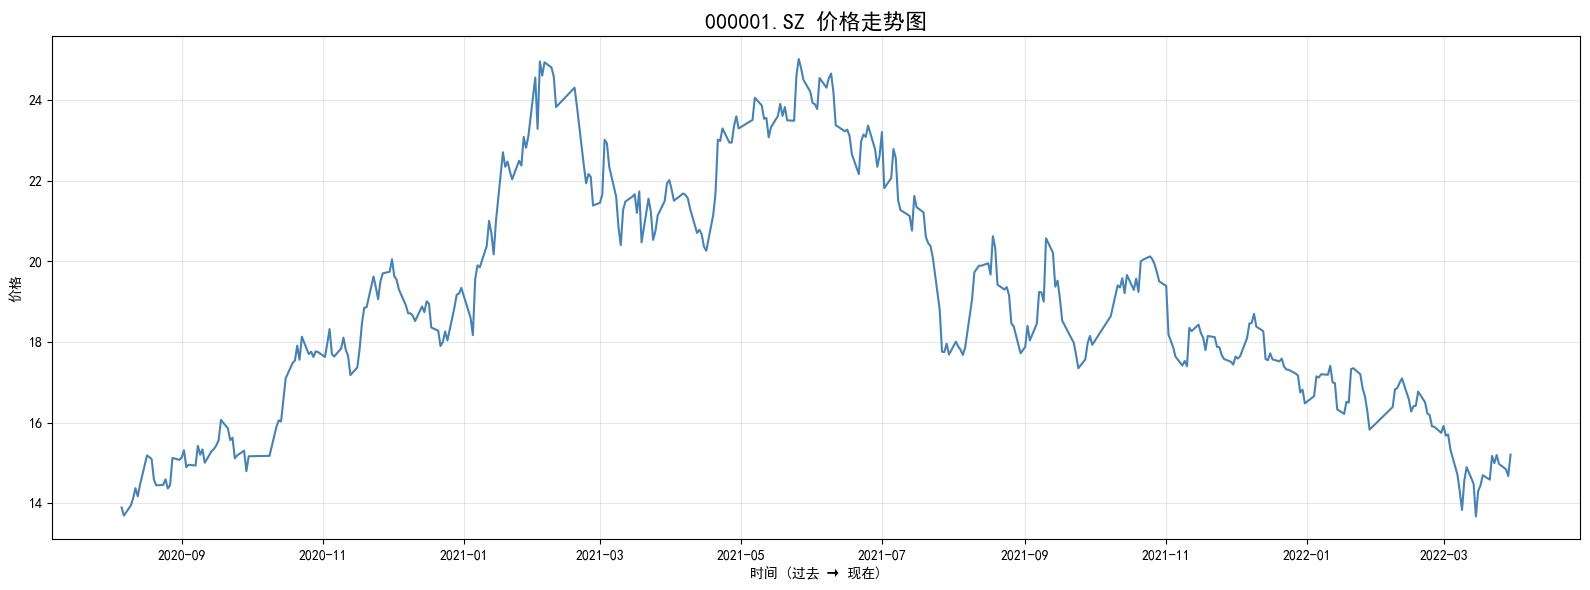

正在生成热力图（原始数据）...


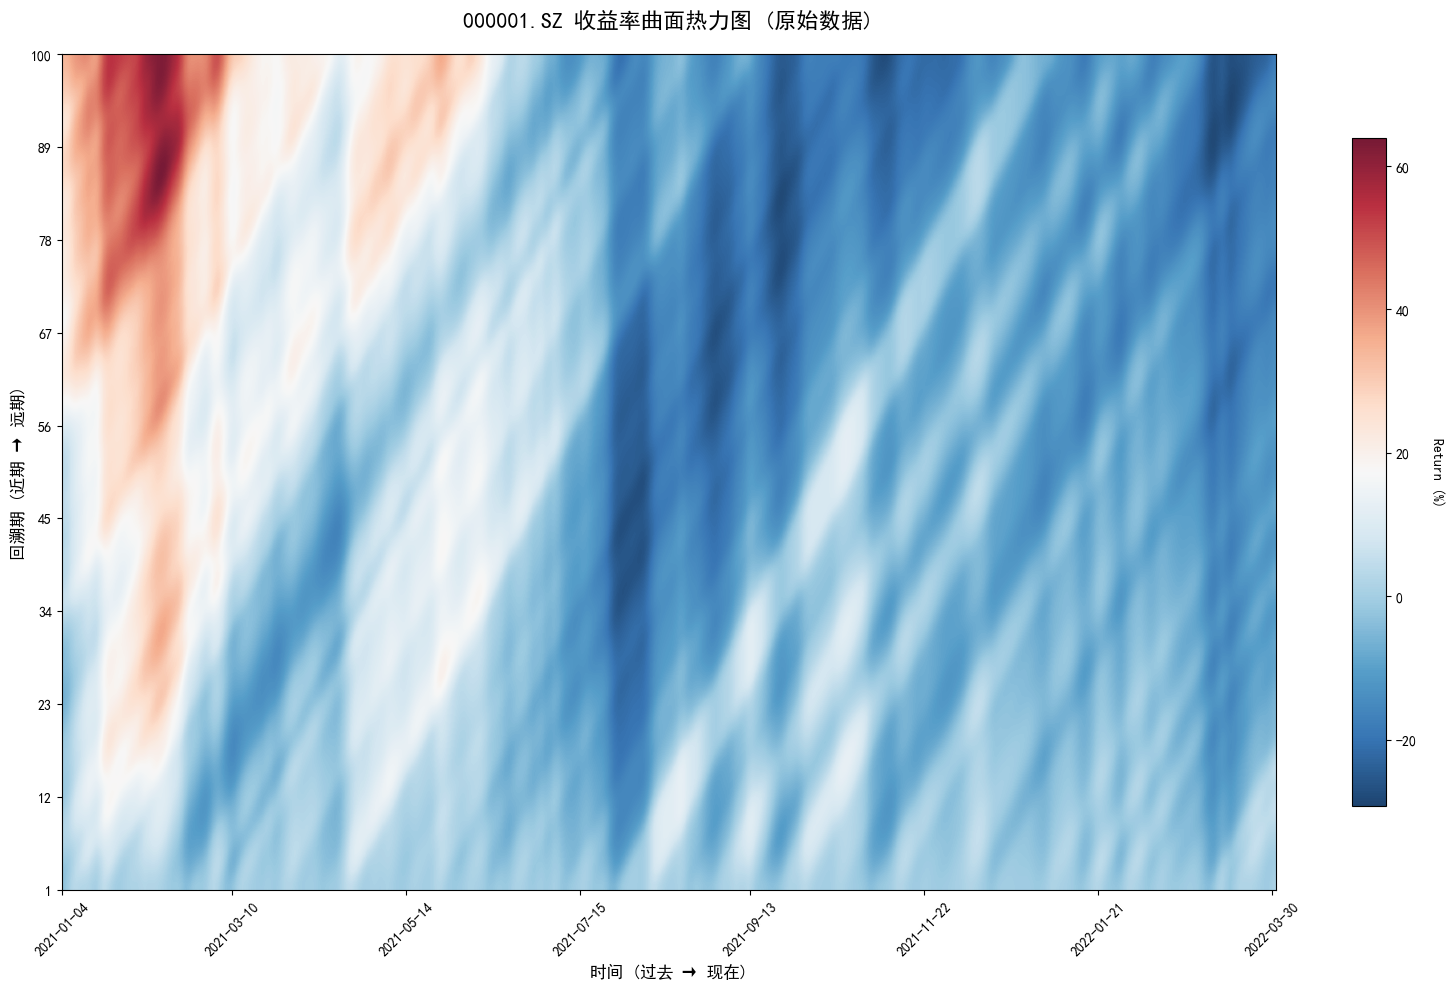

正在生成3D曲面图（原始数据）...


C:\Users\Admin\AppData\Local\Temp\ipykernel_24088\1910978959.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


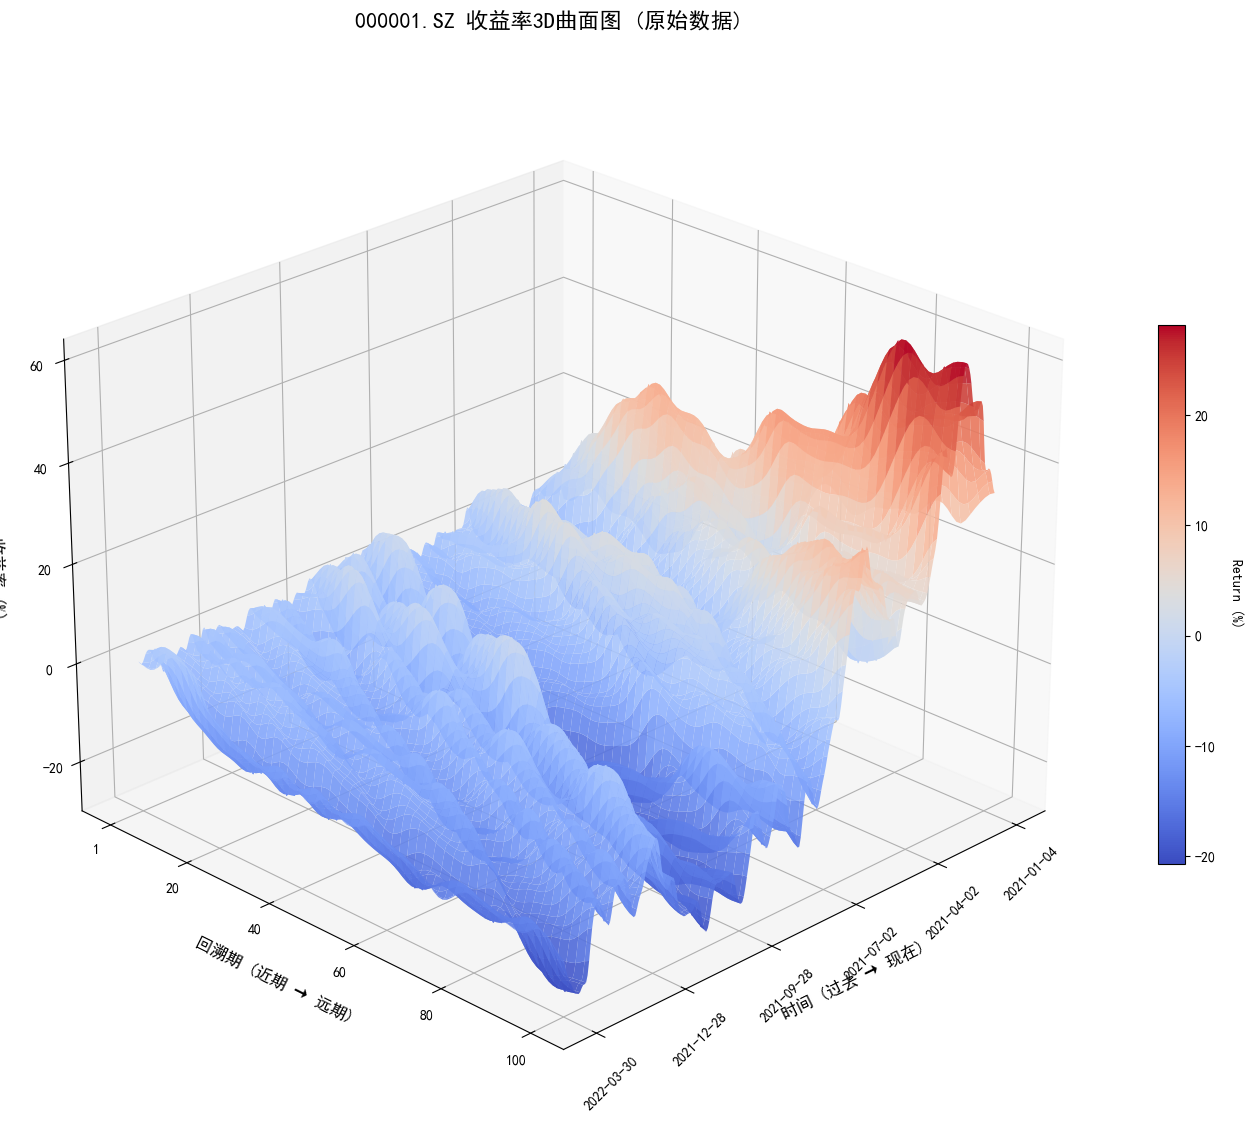


统计分析:
数据时间范围: 2020-08-06 到 2022-03-30
总数据点数: 400
最大回溯期: 100
有效数据点数: 30000
收益率均值: -0.6062%
收益率标准差: 15.5121%
最小收益率: -32.0080%
最大收益率: 68.5811%

不同回溯期的平均收益率:
回溯1期: -0.0503%
回溯5期: -0.2398%
回溯10期: -0.4564%
回溯20期: -1.1257%
回溯50期: -1.6901%
回溯100期: 2.5152%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import os
from scipy import ndimage
import matplotlib.colors as colors
from matplotlib import cm

# 设置中文字体（如果需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.rcParams['figure.figsize'] = (12, 8)  # 设置默认图形大小

ts_code = "000001.SZ"
analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"
df = pd.read_csv(csv_path, parse_dates=['trade_date'], index_col="trade_date", nrows=400)

# 确保数据按日期排序
df = df.sort_index()

# 定义最大回溯期
max_lookback = 100

# 计算回报率矩阵函数
def calculate_return_matrix(df, max_lookback):
    """
    计算每个时间点和每个回溯期的回报率矩阵
    """
    close_prices = df['close'].values
    n_periods = len(close_prices)
    
    # 初始化回报率矩阵
    return_matrix = np.full((n_periods, max_lookback), np.nan)
    
    # 计算每个时间点和每个回溯期的回报率
    for t in range(max_lookback, n_periods):
        for n in range(1, max_lookback + 1):
            if t - n >= 0:
                return_matrix[t, n-1] = (close_prices[t] - close_prices[t-n]) / close_prices[t-n]
    
    return return_matrix

# 计算回报率矩阵
return_matrix = calculate_return_matrix(df, max_lookback)

# 创建时间索引和回溯期索引
time_index = df.index[max_lookback:]
lookback_index = np.arange(1, max_lookback + 1)

# 创建符合人类习惯的热力图（只使用原始数据）
def plot_heatmap_original(return_matrix, time_index, lookback_index):
    # 使用有效数据部分
    valid_data = return_matrix[max_lookback:]
    
    # 对数据进行轻微平滑处理
    smoothed_data = ndimage.gaussian_filter(valid_data.T, sigma=1.0)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # 创建热力图 - 时间从左到右，回溯期从下到上
    im = ax.imshow(
        smoothed_data * 100,  # 转换为百分比
        aspect='auto',
        cmap='RdBu_r',
        origin='lower',
        interpolation='gaussian',
        alpha=0.9,
        extent=[0, len(time_index), 1, max_lookback]
    )
    
    # 添加颜色条
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Return (%)', rotation=270, labelpad=20)
    
    # 设置标签
    ax.set_title(f'{ts_code} 收益率曲面热力图 (原始数据)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('时间 (过去 → 现在)', fontsize=12)
    ax.set_ylabel('回溯期 (近期 → 远期)', fontsize=12)
    
    # 设置刻度
    time_ticks = np.linspace(0, len(time_index)-1, 8).astype(int)
    ax.set_xticks(time_ticks)
    ax.set_xticklabels([time_index[i].strftime('%Y-%m-%d') for i in time_ticks], rotation=45)
    
    lookback_ticks = np.linspace(1, max_lookback, 10).astype(int)
    ax.set_yticks(lookback_ticks)
    ax.set_yticklabels(lookback_ticks)
    
    plt.tight_layout()
    plt.show()

# 创建符合人类习惯的3D曲面图（使用原始数据）
def plot_3d_original(return_matrix, time_index, lookback_index):
    # 使用有效数据部分
    valid_data = return_matrix[max_lookback:]
    Z = valid_data.T * 100  # 转换为百分比
    
    # 对数据进行平滑处理，使曲面更美观
    Z_smooth = ndimage.gaussian_filter(Z, sigma=1.5)
    
    # 创建图形
    fig = plt.figure(figsize=(18, 14))
    ax = fig.add_subplot(111, projection='3d')
    
    # 创建网格 - 确保X, Y, Z的形状匹配
    # 时间维度 (从左到右: 过去到现在)
    # 回溯期维度 (从下到上: 近期到远期)
    X, Y = np.meshgrid(
        np.arange(len(time_index)),  # 时间维度
        np.arange(Z.shape[0])        # 回溯期维度
    )
    
    # 计算数据的百分位数，用于设置颜色映射范围
    vmin = np.nanpercentile(Z_smooth, 5)
    vmax = np.nanpercentile(Z_smooth, 95)
    
    # 创建自定义颜色映射，增强对比度
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    # 使用发散色彩映射，增强正负值的对比
    colorscale = cm.coolwarm
    
    # 绘制曲面
    surf = ax.plot_surface(
        X, Y, Z_smooth,
        cmap=colorscale,
        rstride=2,
        cstride=2,
        alpha=0.9,
        linewidth=0.5,
        antialiased=True,
        shade=True
    )
    
    # 添加颜色条
    mappable = cm.ScalarMappable(norm=norm, cmap=colorscale)
    mappable.set_array(Z_smooth)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=20)
    cbar.set_label('Return (%)', rotation=270, labelpad=20)
    
    # 设置视角 - 从斜上方观察
    ax.view_init(elev=25, azim=45)
    
    # 设置标签
    ax.set_title(f'{ts_code} 收益率3D曲面图 (原始数据)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('时间 (过去 → 现在)', fontsize=12, labelpad=10)
    ax.set_ylabel('回溯期 (近期 → 远期)', fontsize=12, labelpad=10)
    ax.set_zlabel('收益率 (%)', fontsize=12, labelpad=10)
    
    # 设置刻度标签
    time_ticks = np.linspace(0, len(time_index)-1, 6).astype(int)
    ax.set_xticks(time_ticks)
    ax.set_xticklabels([time_index[i].strftime('%Y-%m-%d') for i in time_ticks], rotation=45)
    
    lookback_ticks = np.linspace(0, Z.shape[0]-1, 6).astype(int)
    ax.set_yticks(lookback_ticks)
    ax.set_yticklabels(lookback_index[lookback_ticks])
    
    plt.tight_layout()
    plt.show()

# 绘制价格走势图作为参考
def plot_price_chart(df):
    plt.figure(figsize=(16, 6))
    plt.plot(df.index, df['close'], linewidth=1.5, color='steelblue')
    plt.title(f'{ts_code} 价格走势图', fontsize=16, fontweight='bold')
    plt.xlabel('时间 (过去 → 现在)')
    plt.ylabel('价格')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 绘制图形
print("生成价格走势图...")
plot_price_chart(df)

print("正在生成热力图（原始数据）...")
plot_heatmap_original(return_matrix, time_index, lookback_index)

print("正在生成3D曲面图（原始数据）...")
plot_3d_original(return_matrix, time_index, lookback_index)

# 添加一些统计分析
print("\n统计分析:")
print(f"数据时间范围: {df.index[0].strftime('%Y-%m-%d')} 到 {df.index[-1].strftime('%Y-%m-%d')}")
print(f"总数据点数: {len(df)}")
print(f"最大回溯期: {max_lookback}")

# 计算整个曲面的统计量
valid_data = return_matrix[max_lookback:]
flat_returns = valid_data.flatten()
flat_returns = flat_returns[~np.isnan(flat_returns)]  # 移除NaN值

print(f"有效数据点数: {len(flat_returns)}")
print(f"收益率均值: {np.mean(flat_returns)*100:.4f}%")
print(f"收益率标准差: {np.std(flat_returns)*100:.4f}%")
print(f"最小收益率: {np.min(flat_returns)*100:.4f}%")
print(f"最大收益率: {np.max(flat_returns)*100:.4f}%")

# 分析不同回溯期的表现
print("\n不同回溯期的平均收益率:")
for n in [1, 5, 10, 20, 50, 100]:
    if n <= max_lookback:
        returns = valid_data[:, n-1]
        returns = returns[~np.isnan(returns)]
        if len(returns) > 0:
            print(f"回溯{n}期: {np.mean(returns)*100:.4f}%")